# Self Reflection

In [1]:
from langchain_text_splitters import RecursiveCharacterTextSplitter,CharacterTextSplitter
from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import Chroma,FAISS
import fitz  
import warnings
#utility
import numpy as np
from typing import List,Dict,Any
from sentence_transformers import SentenceTransformer

from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langchain_core.runnables import (RunnablePassthrough,RunnableMap)
from langchain_core.output_parsers import StrOutputParser
import os
import numpy as np
from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever
from langchain_core.documents import Document

from langchain_classic.chains.combine_documents import create_stuff_documents_chain
from langchain_classic.chains.retrieval import create_retrieval_chain
from langchain_classic.document_loaders import WikipediaLoader
from PIL import Image
import torch
from transformers import CLIPProcessor,CLIPModel
import base64
import io
from langchain.messages import SystemMessage,HumanMessage,AIMessage,AnyMessage
from pydantic import BaseModel,Field
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware,HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.messages import HumanMessage,SystemMessage
from langchain.tools import tool
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from IPython.display import Image,display

## Reducers
from typing import Annotated
from typing import Literal
from langgraph.graph.message import add_messages
import random
from  dataclasses import dataclass
from pydantic import BaseModel,Field
from pprint import pprint
from langgraph.graph.message import add_messages
from typing import Annotated
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langgraph.checkpoint.memory import MemorySaver
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.document_loaders import WebBaseLoader
from langchain_groq import ChatGroq
warnings.filterwarnings("ignore")

C:\Users\kanha\AppData\Local\Temp\ipykernel_29300\1667872069.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader,PyMuPDFLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
from pydantic import BaseModel,Field

In [3]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [4]:
docs=TextLoader("research_notes.txt",encoding="utf-8").load()
splitter=RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap=50)
chunks=splitter.split_documents(docs)
embeddings=HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"

)
from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)
vectorstore=FAISS.from_documents(chunks,embeddings)
retriever=vectorstore.as_retriever()
retriever

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

VectorStoreRetriever(tags=['FAISS', 'HuggingFaceEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAISS object at 0x0000018743D28650>, search_kwargs={})

In [15]:
from pydantic import BaseModel, Field

class RAGState(BaseModel):
    question: str
    sub_steps: List[str] = Field(default_factory=list)
    retrieved_docs: List[Document] = Field(default_factory=list)
    answer: str = ""
    revised:bool=False
    attempts:int=0
    reflection:str=""

In [16]:
def retrieve_docs(state:RAGState)->RAGState:
    docs=retriever.invoke(state.question)
    return state.model_copy(update={"retrieved_docs":docs})

def generate_answer(state:RAGState)->RAGState:
    context="\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt=f"""
    Use the following content to answer the question:
    Context:
    {context}

    Question:
    {state.question}

    """
    answer= llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer":answer,"attempts":state.attempts+1})
def reflect_on_answer(state:RAGState)->RAGState:
    prompt=f"""
    Reflect on the following answer to see if fully addresses the question.
    State Yes if it is complete and correct, or No with an explanation.

    Question:{state.question}
    Answer:{state.answer}
    
    """
    result=llm.invoke(prompt).content
    is_ok="reflection:yes"in result.lower()
    return state.model_copy(update={"reflection":result,"revised":not is_ok})
def finalize(state:RAGState)->RAGState:
    return state
    
    

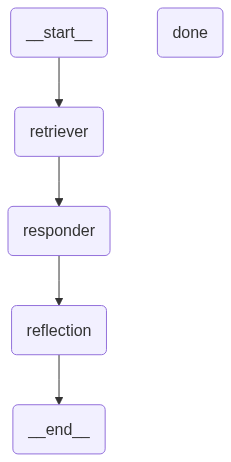

In [17]:
builder=StateGraph(RAGState)

builder.add_node("retriever",retrieve_docs)
builder.add_node("responder",generate_answer)
builder.add_node("reflection",reflect_on_answer)
builder.add_node("done",finalize)
builder.set_entry_point("retriever")

builder.add_edge('retriever',"responder")
builder.add_edge("responder","reflection")
builder.add_conditional_edges(
    "reflection",
    lambda s: "done" if not  s.revised or s.attempts>=2 else "retriever"
)
builder.add_edge("done",END)
graph=builder.compile()
graph

In [18]:
if __name__=="__main__":
    query="How do agent loops work and why are they useful in AI systems?"
    state=RAGState(question=query)
    final=graph.invoke(state)

    
    print("\n Final answer\n", final['answer'])
    print("\n Reflection\n",final['reflection'])
    print("\n Attempts \n",final['attempts'])
    


 Final answer
 The provided content does not specifically explain how agent loops work. However, it mentions that **LangGraph** enables stateful, graph-based workflows with conditional branching, loops, multi-agent collaboration, and human-in-the-loop interactions.

Although the content does not provide detailed information on agent loops, we can infer that agent loops are likely a feature of LangGraph that allows agents to interact with each other or with external tools in a repetitive or iterative manner. This could be useful in AI systems for several reasons:

1. **Iterative refinement**: Agent loops could enable agents to refine their decisions or outputs through repeated interactions, allowing them to converge on a more accurate or optimal solution.
2. **Dynamic decision-making**: Loops could facilitate dynamic decision-making by allowing agents to adapt to changing circumstances or new information, making them more responsive and effective in real-world applications.
3. **Multi-